# Generalized Linear Models (GLMs)

## Introduction

**Generalized Linear Models** extend ordinary linear regression to response variables that have non-normal error distributions. They unify a broad family of regression models under a single framework.

### The GLM Framework

A GLM consists of three components:

1. **Random Component**: The response $Y$ follows an exponential family distribution:
   $$f(y; \theta, \phi) = \exp\left(\frac{y\theta - b(\theta)}{a(\phi)} + c(y, \phi)\right)$$

2. **Systematic Component**: A linear predictor:
   $$\eta = \mathbf{x}^T \boldsymbol{\beta} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

3. **Link Function**: Connects the mean $\mu = E[Y]$ to the linear predictor:
   $$g(\mu) = \eta \quad \Leftrightarrow \quad \mu = g^{-1}(\eta)$$

### Common GLM Families

| Distribution | Canonical Link | Use Case |
|---|---|---|
| Gaussian | Identity $\eta = \mu$ | Continuous outcomes |
| Binomial | Logit $\log\frac{\mu}{1-\mu}$ | Binary/proportion data |
| Poisson | Log $\log(\mu)$ | Count data |
| Gamma | Inverse $1/\mu$ | Positive continuous |
| Inverse Gaussian | $1/\mu^2$ | Positive skewed |

### Estimation via IRLS

Parameters are estimated by **Iteratively Reweighted Least Squares (IRLS)**:
$$\boldsymbol{\beta}^{(t+1)} = (\mathbf{X}^T \mathbf{W}^{(t)} \mathbf{X})^{-1} \mathbf{X}^T \mathbf{W}^{(t)} \mathbf{z}^{(t)}$$

where $\mathbf{W}$ is a diagonal weight matrix and $\mathbf{z}$ is the adjusted dependent variable.


GLM Framework Demo
Gaussian response range: [-2.41, 6.71]
Poisson response range:  [0, 13]
Binomial response range: [0, 1]


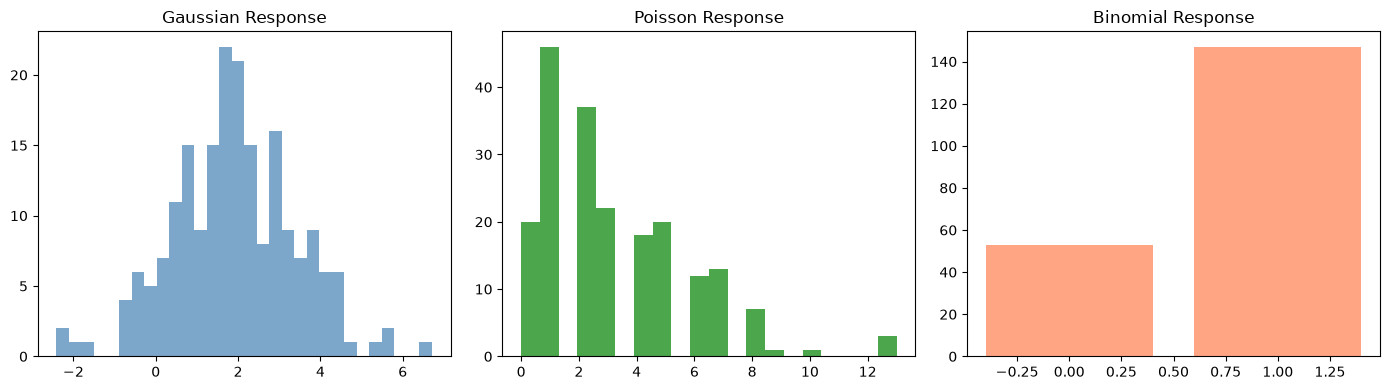

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Demonstrate the GLM framework with different families
np.random.seed(42)
n = 200
X = np.random.randn(n, 2)

# Gaussian GLM (standard linear regression)
y_gaussian = 2 + X[:,0] - 0.5*X[:,1] + np.random.randn(n)

# Poisson GLM
eta = 1 + 0.5*X[:,0] - 0.3*X[:,1]
y_poisson = np.random.poisson(np.exp(eta))

# Binomial GLM
p = 1 / (1 + np.exp(-eta))
y_binomial = np.random.binomial(1, p)

print('GLM Framework Demo')
print('='*40)
print(f'Gaussian response range: [{y_gaussian.min():.2f}, {y_gaussian.max():.2f}]')
print(f'Poisson response range:  [{y_poisson.min()}, {y_poisson.max()}]')
print(f'Binomial response range: [{y_binomial.min()}, {y_binomial.max()}]')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(y_gaussian, bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Gaussian Response')
axes[1].hist(y_poisson, bins=20, color='green', alpha=0.7)
axes[1].set_title('Poisson Response')
axes[2].bar([0,1], [np.sum(y_binomial==0), np.sum(y_binomial==1)], color='coral', alpha=0.7)
axes[2].set_title('Binomial Response')
plt.tight_layout()
plt.show()


## 2. Ordinal Regression (Proportional Odds Model)

**Ordinal regression** is used when the response variable is ordinal categories with a natural order but unknown distances between them (e.g., survey responses: Strongly Disagree < Disagree < Neutral < Agree < Strongly Agree).

### Proportional Odds Model

The **cumulative logit model** (proportional odds model) is:
$$\text{logit}[P(Y \leq j | \mathbf{x})] = \alpha_j - \boldsymbol{\beta}^T \mathbf{x}, \quad j = 1, \ldots, J-1$$

where $\alpha_1 \leq \alpha_2 \leq \cdots \leq \alpha_{J-1}$ are threshold parameters (intercepts) and $\boldsymbol{\beta}$ is the common coefficient vector.

### Proportional Odds Assumption

The **odds ratio** of $Y \leq j$ vs $Y > j$ is constant across all $j$:
$$\frac{P(Y \leq j | x+1) / P(Y > j | x+1)}{P(Y \leq j | x) / P(Y > j | x)} = e^{-\beta}$$

This means a one-unit increase in $x$ multiplies the odds of being in category $\leq j$ (vs $> j$) by $e^{-\beta}$, for every $j$.

### Category Probabilities

$$P(Y = j | \mathbf{x}) = P(Y \leq j | \mathbf{x}) - P(Y \leq j-1 | \mathbf{x})$$

### Log-Likelihood

$$\ell(\alpha, \beta) = \sum_{i=1}^n \log P(Y_i = y_i | \mathbf{x}_i)$$

### Intuition

Think of the ordinal outcome as arising from a latent continuous variable $Y^* = \boldsymbol{\beta}^T \mathbf{x} + \epsilon$, where $\epsilon$ follows a logistic distribution. The observed category is determined by which threshold $Y^*$ falls between.


Scratch Ordinal Regression:
  Coefficients: [ 0.58511507 -0.51770073]
  Thresholds:   [0.         0.59387281 1.43628983]



Statsmodels Ordered Logit:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.6417      0.092      6.942      0.000       0.461       0.823
x2            -0.5810      0.088     -6.582      0.000      -0.754      -0.408
0/1           -0.9575      0.104     -9.199      0.000      -1.162      -0.754
1/2           -0.1006      0.096     -1.047      0.295      -0.289       0.088
2/3            0.0513      0.089      0.574      0.566      -0.124       0.227


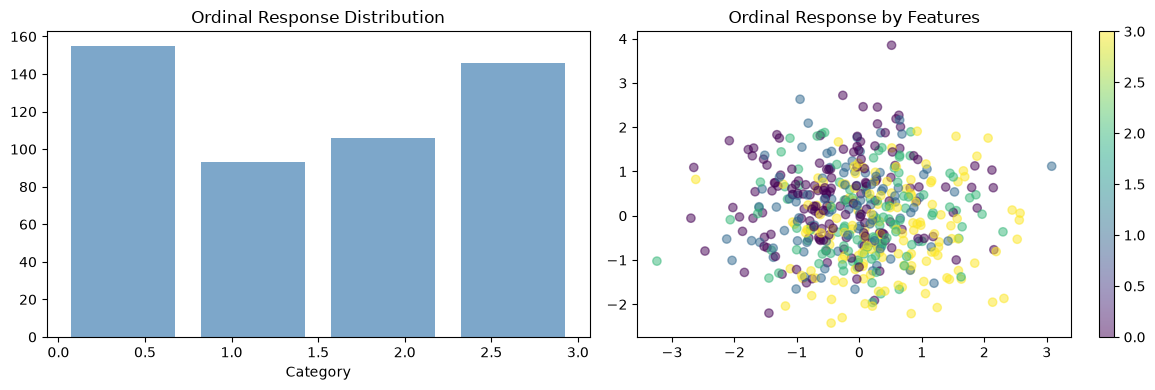

In [2]:
import numpy as np
import pandas as pd
from scipy.special import expit  # sigmoid
from scipy.optimize import minimize

# ---- Scratch implementation of Proportional Odds Model ----
class OrdinalLogisticRegression:
    def __init__(self):
        self.thresholds_ = None
        self.coef_ = None
        self.classes_ = None

    def _cumulative_probs(self, X, thresholds, beta):
        eta = X @ beta
        cum_probs = expit(thresholds[:, None] - eta[None, :])
        return cum_probs  # shape (J-1, n)

    def _neg_log_likelihood(self, params, X, y, J):
        beta = params[:X.shape[1]]
        raw_thresh = params[X.shape[1]:]
        # Ensure ordered thresholds via cumulative sum
        thresholds = np.cumsum(np.exp(raw_thresh))
        thresholds = thresholds - thresholds[0]  # shift
        thresholds = np.concatenate([[-1000], thresholds, [1000]])

        eta = X @ beta
        log_lik = 0
        for i in range(len(y)):
            j = y[i]
            p_leq_j = expit(thresholds[j+1] - eta[i])
            p_leq_jm1 = expit(thresholds[j] - eta[i])
            p_j = p_leq_j - p_leq_jm1
            p_j = max(p_j, 1e-10)
            log_lik += np.log(p_j)
        return -log_lik

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        J = len(self.classes_)
        y_encoded = np.searchsorted(self.classes_, y)
        p = X.shape[1]
        params0 = np.zeros(p + J - 1)
        params0[p:] = np.log(np.ones(J-1))
        res = minimize(self._neg_log_likelihood, params0,
                      args=(X, y_encoded, J), method='L-BFGS-B')
        self.coef_ = res.x[:p]
        raw_thresh = res.x[p:]
        thresh = np.cumsum(np.exp(raw_thresh))
        self.thresholds_ = thresh - thresh[0]
        return self

# Generate ordinal data
np.random.seed(42)
n = 500
X_ord = np.random.randn(n, 2)
latent = 0.8 * X_ord[:, 0] - 0.5 * X_ord[:, 1] + np.random.logistic(size=n)
thresholds_true = [-1, 0, 1]
y_ord = np.digitize(latent, thresholds_true)  # 0,1,2,3

model_ord = OrdinalLogisticRegression()
model_ord.fit(X_ord, y_ord)
print('Scratch Ordinal Regression:')
print(f'  Coefficients: {model_ord.coef_}')
print(f'  Thresholds:   {model_ord.thresholds_}')

# Using statsmodels
try:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
    df_ord = pd.DataFrame(X_ord, columns=['x1', 'x2'])
    df_ord['y'] = pd.Categorical(y_ord, ordered=True)
    mod = OrderedModel(df_ord['y'], df_ord[['x1', 'x2']], distr='logit')
    res = mod.fit(method='bfgs', disp=False)
    print('\nStatsmodels Ordered Logit:')
    print(res.summary().tables[1])
except Exception as e:
    print(f'statsmodels ordinal: {e}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_ord, bins=4, rwidth=0.8, color='steelblue', alpha=0.7)
axes[0].set_title('Ordinal Response Distribution')
axes[0].set_xlabel('Category')
scatter = axes[1].scatter(X_ord[:,0], X_ord[:,1], c=y_ord, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, ax=axes[1])
axes[1].set_title('Ordinal Response by Features')
plt.tight_layout()
plt.show()


## 3. Poisson Regression

**Poisson regression** models count data non-negative integers such as number of accidents, disease cases, or website visits.

### Model

$$Y_i \sim \text{Poisson}(\mu_i), \quad \log(\mu_i) = \mathbf{x}_i^T \boldsymbol{\beta}$$

The **log link** ensures $\mu_i > 0$:
$$\mu_i = \exp(\mathbf{x}_i^T \boldsymbol{\beta})$$

### Log-Likelihood

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log \mu_i - \mu_i - \log(y_i!) \right]$$

Dropping the constant term:
$$\ell(\mu) = \sum y_i \log \mu_i - \mu_i$$

### Score Equations

$$\frac{\partial \ell}{\partial \boldsymbol{\beta}} = \mathbf{X}^T (\mathbf{y} - \boldsymbol{\mu}) = \mathbf{0}$$

### Offset Terms

For **rate models**, include an offset to model rates per unit exposure $t_i$:
$$\log(\mu_i) = \log(t_i) + \mathbf{x}_i^T \boldsymbol{\beta}$$

### Equidispersion Assumption

Poisson requires $E[Y] = \text{Var}[Y] = \mu$. When variance exceeds the mean (**overdispersion**), use Negative Binomial instead.

### Intuition

The multiplicative nature of the log link means: a one-unit increase in $x_j$ **multiplies** the expected count by $e^{\beta_j}$ (incident rate ratio).


Scratch Poisson Regression Coefficients:
  Intercept: -0.4439
  Age (std):     0.5726
  Smoking (std): 0.1808



Statsmodels Poisson Regression:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1930      0.267     -8.216      0.000      -2.716      -1.670
x1             0.0325      0.004      7.776      0.000       0.024       0.041
x2             0.3774      0.135      2.786      0.005       0.112       0.643

Incident Rate Ratios: [0.11157773 1.03301049 1.45843663]


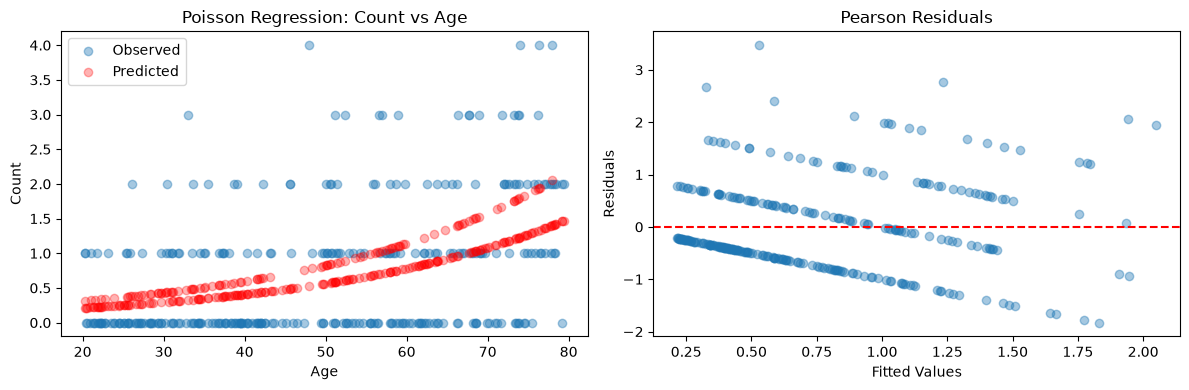

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import factorial

# ---- Scratch Poisson Regression ----
class PoissonRegression:
    def __init__(self, max_iter=100, lr=0.01):
        self.max_iter = max_iter
        self.lr = lr
        self.coef_ = None

    def _log_likelihood(self, beta, X, y):
        mu = np.exp(X @ beta)
        return np.sum(y * np.log(mu + 1e-10) - mu)

    def _gradient(self, beta, X, y):
        mu = np.exp(X @ beta)
        return X.T @ (y - mu)

    def fit(self, X, y):
        X_b = np.column_stack([np.ones(len(X)), X])
        beta = np.zeros(X_b.shape[1])
        for _ in range(self.max_iter):
            grad = self._gradient(beta, X_b, y)
            # IRLS: use Newton step
            mu = np.exp(X_b @ beta)
            W = np.diag(mu)
            H = -X_b.T @ W @ X_b
            beta = beta - np.linalg.solve(H, grad)
        self.coef_ = beta
        return self

    def predict(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return np.exp(X_b @ self.coef_)

# Generate count data: hospital admissions based on age and smoking
np.random.seed(42)
n = 300
age = np.random.uniform(20, 80, n)
smoking = np.random.binomial(1, 0.35, n)
log_mu = -2 + 0.03 * age + 0.5 * smoking
y_count = np.random.poisson(np.exp(log_mu))

X_pois = np.column_stack([age, smoking])
X_pois_std = (X_pois - X_pois.mean(axis=0)) / X_pois.std(axis=0)

# Scratch
model_pois = PoissonRegression(max_iter=50)
model_pois.fit(X_pois_std, y_count)
print('Scratch Poisson Regression Coefficients:')
print(f'  Intercept: {model_pois.coef_[0]:.4f}')
print(f'  Age (std):     {model_pois.coef_[1]:.4f}')
print(f'  Smoking (std): {model_pois.coef_[2]:.4f}')

# Using statsmodels
import statsmodels.api as sm
X_sm = sm.add_constant(X_pois)
pois_sm = sm.Poisson(y_count, X_sm).fit(disp=False)
print('\nStatsmodels Poisson Regression:')
print(pois_sm.summary().tables[1])
print(f'\nIncident Rate Ratios: {np.exp(pois_sm.params)}')

# Visualize fit
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pred = pois_sm.predict(X_sm)
axes[0].scatter(age, y_count, alpha=0.4, label='Observed')
sort_idx = np.argsort(age)
axes[0].scatter(age[sort_idx], pred[sort_idx], alpha=0.3, color='red', label='Predicted')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Poisson Regression: Count vs Age')
axes[0].legend()
axes[1].scatter(pred, y_count - pred, alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Pearson Residuals')
plt.tight_layout()
plt.show()


## 4. Negative Binomial Regression

When count data exhibits **overdispersion** ($\text{Var}[Y] > E[Y]$), the Poisson assumption breaks down. The **Negative Binomial** model adds a dispersion parameter $r$ to accommodate extra variance.

### NB2 Parameterization

$$Y_i \sim \text{NegBin}(\mu_i, r), \quad P(Y = y) = \binom{y+r-1}{y} \left(\frac{r}{r+\mu}\right)^r \left(\frac{\mu}{r+\mu}\right)^y$$

Mean and variance:
$$E[Y] = \mu, \quad \text{Var}[Y] = \mu + \frac{\mu^2}{r}$$

As $r \to \infty$, $\text{Var}[Y] \to \mu$ (recovers Poisson).

### Log Link

$$\log(\mu_i) = \mathbf{x}_i^T \boldsymbol{\beta}$$

### Log-Likelihood

$$\ell(\boldsymbol{\beta}, r) = \sum_{i=1}^n \left[ \log \Gamma(y_i + r) - \log \Gamma(r) - \log(y_i!) + r \log\frac{r}{r+\mu_i} + y_i \log\frac{\mu_i}{r+\mu_i} \right]$$

### Overdispersion Test

The **dispersion statistic**: $\hat{\phi} = \frac{\sum (y_i - \hat{\mu}_i)^2 / \hat{\mu}_i}{n - p}$. Values $\gg 1$ indicate overdispersion.

### Intuition

Think of NB as a **Poisson-Gamma mixture**: $Y | \lambda \sim \text{Poisson}(\lambda)$ where $\lambda \sim \text{Gamma}(r, r/\mu)$. The gamma mixing introduces extra variance.


Variance / Mean ratio: 7.38 (>1 indicates overdispersion)

Poisson AIC:          2625.65
Negative Binomial AIC: 2099.57
(Lower AIC is better NB should win on overdispersed data)

NB Coefficients:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5435      0.043     36.161      0.000       1.460       1.627
x1             0.4897      0.043     11.419      0.000       0.406       0.574
x2            -0.3148      0.044     -7.196      0.000      -0.401      -0.229
alpha          0.4710      0.050      9.394      0.000       0.373       0.569


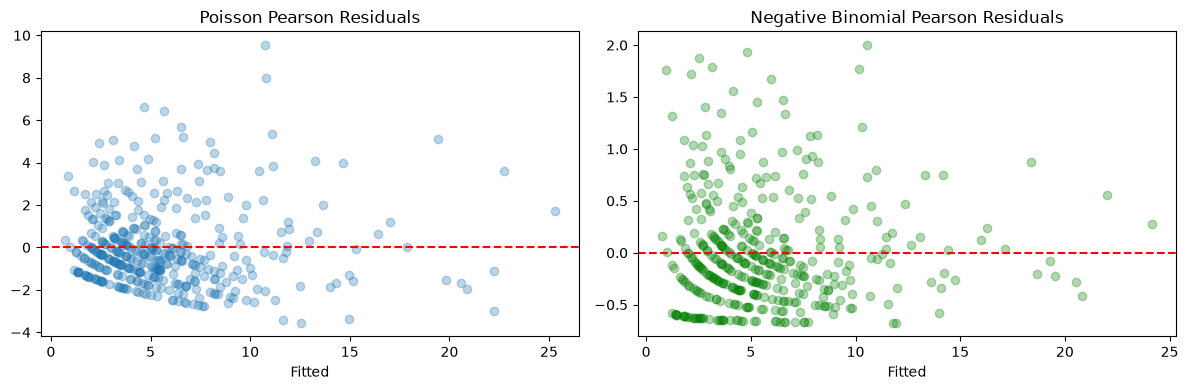

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.special import gammaln
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ---- Scratch NB Regression ----
def nb_log_likelihood(params, X, y):
    beta = params[:-1]
    log_r = params[-1]
    r = np.exp(log_r)  # ensure r > 0
    mu = np.exp(X @ beta)
    ll = (gammaln(y + r) - gammaln(r) - gammaln(y + 1)
          + r * np.log(r / (r + mu))
          + y * np.log(mu / (r + mu)))
    return -np.sum(ll)

# Generate overdispersed count data
np.random.seed(42)
n = 400
X1 = np.random.randn(n)
X2 = np.random.randn(n)
mu_true = np.exp(1.5 + 0.4*X1 - 0.3*X2)
r_true = 2.0  # dispersion
# NB: sample via Poisson-Gamma mixture
lambda_mix = np.random.gamma(r_true, mu_true / r_true)
y_nb = np.random.poisson(lambda_mix)

print(f'Variance / Mean ratio: {y_nb.var() / y_nb.mean():.2f} (>1 indicates overdispersion)')

X_nb = sm.add_constant(np.column_stack([X1, X2]))

# Compare Poisson vs NB
pois_fit = sm.Poisson(y_nb, X_nb).fit(disp=False)
nb_fit = sm.NegativeBinomial(y_nb, X_nb).fit(disp=False)

print(f'\nPoisson AIC:          {pois_fit.aic:.2f}')
print(f'Negative Binomial AIC: {nb_fit.aic:.2f}')
print(f'(Lower AIC is better NB should win on overdispersed data)')
print('\nNB Coefficients:')
print(nb_fit.summary().tables[1])

# Visualize overdispersion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mu_pois = pois_fit.predict(X_nb)
mu_nb = nb_fit.predict(X_nb)
pearson_pois = (y_nb - mu_pois) / np.sqrt(mu_pois)
pearson_nb = (y_nb - mu_nb) / np.sqrt(mu_nb * (1 + mu_nb / nb_fit.params[-1]))
axes[0].scatter(mu_pois, pearson_pois, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Poisson Pearson Residuals')
axes[0].set_xlabel('Fitted')
axes[1].scatter(mu_nb, pearson_nb, alpha=0.3, color='green')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Negative Binomial Pearson Residuals')
axes[1].set_xlabel('Fitted')
plt.tight_layout()
plt.show()


## 5. Zero-Inflated Poisson (ZIP)

Many count datasets have **excess zeros** beyond what Poisson predicts. The **Zero-Inflated Poisson (ZIP)** model handles this with a two-part mixture:

### Model

$$P(Y = 0) = \pi + (1-\pi)e^{-\mu}$$
$$P(Y = y) = (1-\pi)\frac{e^{-\mu}\mu^y}{y!}, \quad y = 1, 2, 3, \ldots$$

where:
- $\pi \in [0,1]$ is the **zero-inflation probability** (structural zeros)
- $\mu > 0$ is the Poisson mean for the count process

### Two-Process Interpretation

1. **Zero-inflation process**: With probability $\pi$, always zero (e.g., non-smoker can never have smoking-related counts)
2. **Count process**: With probability $1-\pi$, count follows $\text{Poisson}(\mu)$

### Link Functions

$$\text{logit}(\pi_i) = \mathbf{z}_i^T \boldsymbol{\gamma}, \quad \log(\mu_i) = \mathbf{x}_i^T \boldsymbol{\beta}$$

Note: $\mathbf{z}$ and $\mathbf{x}$ can be different covariate sets.

### Log-Likelihood

$$\ell = \sum_{y_i=0} \log[\pi_i + (1-\pi_i)e^{-\mu_i}] + \sum_{y_i>0} \left[\log(1-\pi_i) - \mu_i + y_i \log \mu_i - \log(y_i!)\right]$$

### When to Use ZIP

- Insurance claims (many policyholders file zero claims)
- Healthcare utilization (healthy people have zero doctor visits)
- Species counts (areas with no habitat have structural zeros)


Actual zeros:           148 (29.6%)
Poisson expected zeros: 12.0 (2.4%)
Excess zeros:           136.0



Scratch ZIP Results:
  Count model beta:        [1.51044322 0.34427796]
  Zero-inflation gamma:    [-0.98197538  0.4080635 ]

Statsmodels ZIP:


                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
inflate_const    -0.9820      0.108     -9.052      0.000      -1.195      -0.769
inflate_x1        0.4081      0.113      3.614      0.000       0.187       0.629
const             1.5104      0.026     58.046      0.000       1.459       1.561
x1                0.3443      0.027     12.845      0.000       0.292       0.397


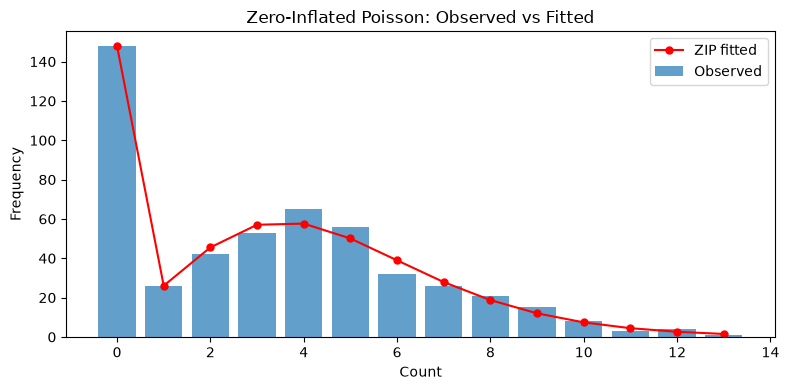

In [5]:
import math
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit, factorial
from scipy.special import gammaln
import matplotlib.pyplot as plt

# ---- Scratch ZIP Model ----
def zip_log_likelihood(params, X, y):
    n_features = X.shape[1]
    beta = params[:n_features]   # count model
    gamma = params[n_features:]  # zero-inflation
    mu = np.exp(X @ beta)
    pi = expit(X @ gamma)
    zero_mask = (y == 0)
    ll_zeros = np.log(pi[zero_mask] + (1 - pi[zero_mask]) * np.exp(-mu[zero_mask]) + 1e-10)
    ll_pos = (np.log(1 - pi[~zero_mask] + 1e-10)
              - mu[~zero_mask]
              + y[~zero_mask] * np.log(mu[~zero_mask] + 1e-10)
              - gammaln(y[~zero_mask] + 1))
    return -(np.sum(ll_zeros) + np.sum(ll_pos))

# Generate ZIP data
np.random.seed(42)
n = 500
X1 = np.random.randn(n)
X_zip = np.column_stack([np.ones(n), X1])

pi_true = expit(-1 + 0.5 * X1)  # zero-inflation probability
mu_true = np.exp(1.5 + 0.4 * X1)

y_zip = np.where(
    np.random.binomial(1, pi_true),
    0,
    np.random.poisson(mu_true)
)

poisson_expected_zeros = np.sum(np.exp(-mu_true))
actual_zeros = np.sum(y_zip == 0)
print(f'Actual zeros:           {actual_zeros} ({100*actual_zeros/n:.1f}%)')
print(f'Poisson expected zeros: {poisson_expected_zeros:.1f} ({100*poisson_expected_zeros/n:.1f}%)')
print(f'Excess zeros:           {actual_zeros - poisson_expected_zeros:.1f}')

# Fit ZIP
params0 = np.zeros(2 * X_zip.shape[1])
res = minimize(zip_log_likelihood, params0, args=(X_zip, y_zip),
               method='L-BFGS-B', options={'maxiter': 500})
n_feat = X_zip.shape[1]
beta_hat = res.x[:n_feat]
gamma_hat = res.x[n_feat:]
print(f'\nScratch ZIP Results:')
print(f'  Count model beta:        {beta_hat}')
print(f'  Zero-inflation gamma:    {gamma_hat}')

# Using statsmodels
try:
    from statsmodels.discrete.count_model import ZeroInflatedPoisson
    zip_sm = ZeroInflatedPoisson(y_zip, X_zip, exog_infl=X_zip).fit(disp=False)
    print('\nStatsmodels ZIP:')
    print(zip_sm.summary().tables[1])
except Exception as e:
    print(f'Statsmodels ZIP: {e}')

# Visualize zero inflation
fig, ax = plt.subplots(figsize=(8, 4))
max_val = min(y_zip.max(), 20)
counts = np.bincount(y_zip)[:max_val+1]
ax.bar(range(max_val+1), counts, alpha=0.7, label='Observed')
mu_pred = np.exp(X_zip @ beta_hat)
pi_pred = expit(X_zip @ gamma_hat)
zip_pmf_0 = np.mean(pi_pred + (1-pi_pred)*np.exp(-mu_pred)) * n
zip_pmf = [zip_pmf_0] + [np.mean((1-pi_pred)*np.exp(-mu_pred)*mu_pred**k / math.factorial(k)) * n for k in range(1, max_val+1)]
ax.plot(range(max_val+1), zip_pmf, 'r-o', label='ZIP fitted', markersize=5)
ax.set_xlabel('Count')
ax.set_ylabel('Frequency')
ax.set_title('Zero-Inflated Poisson: Observed vs Fitted')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Zero-Inflated Negative Binomial (ZINB)

**ZINB** combines zero-inflation with Negative Binomial to handle both **excess zeros** and **overdispersion** simultaneously.

### Model

$$P(Y = 0) = \pi + (1-\pi)\left(\frac{r}{r+\mu}\right)^r$$
$$P(Y = y) = (1-\pi)\binom{y+r-1}{y}\left(\frac{r}{r+\mu}\right)^r\left(\frac{\mu}{r+\mu}\right)^y, \quad y \geq 1$$

### Mean and Variance

$$E[Y] = (1-\pi)\mu$$
$$\text{Var}[Y] = (1-\pi)\mu\left(1 + \mu\pi + \frac{\mu}{r}\right)$$

### Model Selection

| Model | Zeros | Overdispersion |
|---|---|---|
| Poisson | No | No |
| NB | No | Yes |
| ZIP | Yes | No |
| ZINB | Yes | Yes |

Use **AIC/BIC** or **Vuong test** to select between these models.

### Vuong Test

Tests H₀: standard model vs H₁: zero-inflated model:
$$V = \frac{\sqrt{n}\bar{m}}{s_m}, \quad m_i = \log \frac{P_{\text{ZIP}}(y_i)}{P_{\text{Poisson}}(y_i)}$$


ZINB Data Summary:
  Zero fraction:  0.500
  Mean:           2.147
  Variance:       11.865
  Var/Mean ratio: 5.527



ZINB fit converged: True


                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
inflate_const    -0.4146      0.137     -3.020      0.003      -0.684      -0.146
inflate_x1        0.1475      0.117      1.266      0.206      -0.081       0.376
const             1.1981      0.064     18.626      0.000       1.072       1.324
x1                0.4741      0.059      8.098      0.000       0.359       0.589
alpha             0.5406      0.108      5.017      0.000       0.329       0.752

Model Comparison (AIC):
  Poisson: AIC = 3302.04
  NB: AIC = 2217.17
  ZIP: AIC = 2359.44
  ZINB: AIC = 2177.52


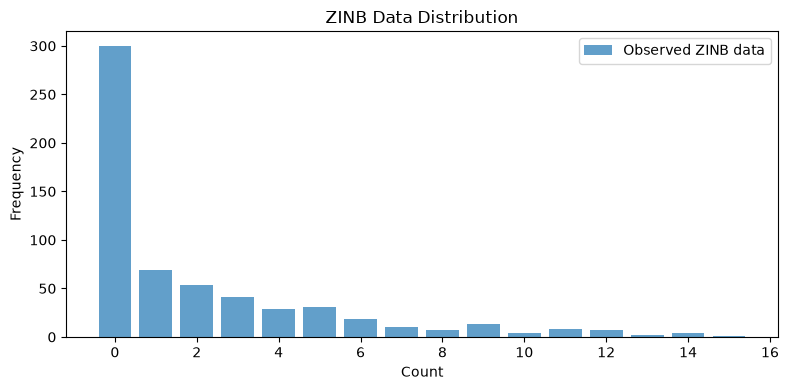

In [6]:
import numpy as np
import pandas as pd
from scipy.special import gammaln, expit
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate ZINB data
np.random.seed(42)
n = 600
X1 = np.random.randn(n)
X_zinb = np.column_stack([np.ones(n), X1])

pi_true = expit(-0.5 + 0.3 * X1)
mu_true = np.exp(1.2 + 0.5 * X1)
r_true = 1.5

# Structural zeros or NB counts
structural_zero = np.random.binomial(1, pi_true).astype(bool)
lambda_mix = np.random.gamma(r_true, mu_true / r_true)
nb_counts = np.random.poisson(lambda_mix)
y_zinb = np.where(structural_zero, 0, nb_counts)

print(f'ZINB Data Summary:')
print(f'  Zero fraction:  {np.mean(y_zinb == 0):.3f}')
print(f'  Mean:           {y_zinb.mean():.3f}')
print(f'  Variance:       {y_zinb.var():.3f}')
print(f'  Var/Mean ratio: {y_zinb.var()/y_zinb.mean():.3f}')

# Fit with statsmodels
try:
    from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
    zinb_sm = ZeroInflatedNegativeBinomialP(y_zinb, X_zinb, exog_infl=X_zinb).fit(disp=False)
    print('\nZINB fit converged:', zinb_sm.mle_retvals['converged'])
    print(zinb_sm.summary().tables[1])
except Exception as e:
    print(f'ZINB fit: {e}')

# Model comparison
try:
    from statsmodels.discrete.count_model import ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP
    from statsmodels.discrete.discrete_model import NegativeBinomial
    models = {}
    models['Poisson'] = sm.Poisson(y_zinb, X_zinb).fit(disp=False)
    models['NB'] = sm.NegativeBinomial(y_zinb, X_zinb).fit(disp=False)
    models['ZIP'] = ZeroInflatedPoisson(y_zinb, X_zinb, exog_infl=X_zinb).fit(disp=False)
    models['ZINB'] = ZeroInflatedNegativeBinomialP(y_zinb, X_zinb, exog_infl=X_zinb).fit(disp=False)
    print('\nModel Comparison (AIC):')
    for name, model in models.items():
        print(f'  {name}: AIC = {model.aic:.2f}')
except Exception as e:
    print(f'Model comparison error: {e}')

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
max_val = min(y_zinb.max(), 15)
counts = np.bincount(y_zinb)[:max_val+1]
ax.bar(range(len(counts)), counts, alpha=0.7, label='Observed ZINB data')
ax.set_xlabel('Count')
ax.set_ylabel('Frequency')
ax.set_title('ZINB Data Distribution')
ax.legend()
plt.tight_layout()
plt.show()


## 6b. Gamma GLM

The **Gamma distribution** is used for positive continuous skewed data such as insurance claim amounts, hospital costs, or repair times. It is never negative and has a long right tail, making it a natural choice when your response variable is strictly positive and right-skewed.

### Why Gamma?

- Response is always positive (e.g., cost, duration, amount)
- Variance grows with the mean (heteroscedastic)
- Data exhibits a long right tail

### Model

$$Y_i \sim \text{Gamma}(\text{shape}, \text{scale}_i), \quad g(\mu_i) = \mathbf{x}_i^T \boldsymbol{\beta}$$

The canonical link is the inverse link $g(\mu) = 1/\mu$, but the **log link** is far more commonly used in practice because it ensures $\mu > 0$ and gives interpretable multiplicative coefficients.

### Variance Function

$$\text{Var}[Y] = \phi \mu^2$$

where $\phi$ is the dispersion parameter. The variance scales as the square of the mean, unlike Poisson where $\text{Var}[Y] = \mu$.

In [7]:
import statsmodels.api as sm
import numpy as np

np.random.seed(42)
n = 500
X_gamma = np.column_stack([np.random.exponential(2, n), np.random.normal(5, 1, n)])
mu = np.exp(0.5 + 0.3 * X_gamma[:,0] + 0.1 * X_gamma[:,1])
shape = 2.0
y_gamma = np.random.gamma(shape=shape, scale=mu/shape, size=n)

X_gamma_sm = sm.add_constant(X_gamma)
gamma_model = sm.GLM(y_gamma, X_gamma_sm, family=sm.families.Gamma(link=sm.families.links.Log()))
gamma_result = gamma_model.fit()
print(gamma_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  500
Model:                            GLM   Df Residuals:                      497
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                         0.46385
Method:                          IRLS   Log-Likelihood:                -1259.9
Date:                Mon, 29 Jun 2026   Deviance:                       255.85
Time:                        15:21:22   Pearson chi2:                     231.
No. Iterations:                    11   Pseudo R-squ. (CS):             0.5825
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5337      0.157      3.396      0.0

## 7. Tobit Model (Censored Regression)

The **Tobit model** handles **censored** response variables outcomes that are constrained to be at or above (below) a threshold, often zero.

### Classic Tobit (Type I)

$$Y_i^* = \mathbf{x}_i^T \boldsymbol{\beta} + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma^2)$$
$$Y_i = \max(0, Y_i^*) = \begin{cases} 0 & \text{if } Y_i^* \leq 0 \\ Y_i^* & \text{if } Y_i^* > 0 \end{cases}$$

The observed $Y_i$ is the **latent** $Y_i^*$ censored at zero.

### Log-Likelihood

$$\ell(\boldsymbol{\beta}, \sigma) = \sum_{y_i=0} \log \Phi\left(-\frac{\mathbf{x}_i^T \boldsymbol{\beta}}{\sigma}\right) + \sum_{y_i>0} \log \phi\left(\frac{y_i - \mathbf{x}_i^T \boldsymbol{\beta}}{\sigma}\right) - \log \sigma$$

where $\Phi$ is the standard normal CDF and $\phi$ is the PDF.

### Conditional Mean

$$E[Y_i | \mathbf{x}_i] = \mathbf{x}_i^T \boldsymbol{\beta} \cdot \Phi\left(\frac{\mathbf{x}_i^T \boldsymbol{\beta}}{\sigma}\right) + \sigma \cdot \phi\left(\frac{\mathbf{x}_i^T \boldsymbol{\beta}}{\sigma}\right)$$

### Why OLS Fails

OLS on censored data gives **biased estimates** it ignores the information that $Y_i = 0$ means $Y_i^* \leq 0$, not that $Y_i^* = 0$.

### Applications

- Consumer expenditure (many households spend $0 on luxury goods)
- Wage equations (wages cannot be negative)
- Hours worked (bounded below at 0)
- Survey responses with floor/ceiling effects


Tobit Data:
  Censored (y=0): 45.8%
  Observed (y>0): 54.2%



Scratch Tobit Results:
  Intercept: 3.578
  Income:    18.802
  Education: 6.878
  Sigma:     15.718



OLS Coefficients (biased):
  Intercept: 12.183
  Income:    10.725
  Education: 4.228


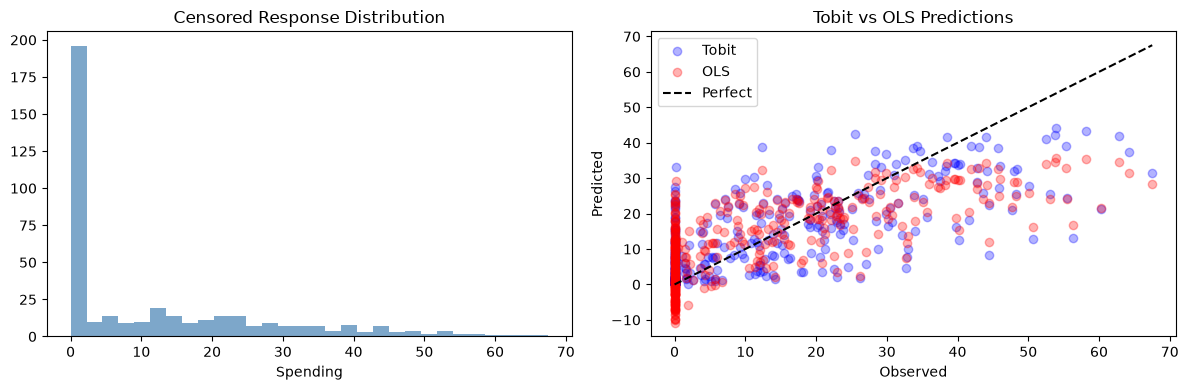

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ---- Scratch Tobit Model ----
def tobit_log_likelihood(params, X, y):
    beta = params[:-1]
    log_sigma = params[-1]
    sigma = np.exp(log_sigma)
    xb = X @ beta
    censored = (y == 0)
    ll_censored = np.sum(norm.logcdf(-xb[censored] / sigma))
    ll_observed = np.sum(norm.logpdf((y[~censored] - xb[~censored]) / sigma) - log_sigma)
    return -(ll_censored + ll_observed)

class TobitModel:
    def fit(self, X, y):
        X_b = np.column_stack([np.ones(len(X)), X])
        params0 = np.zeros(X_b.shape[1] + 1)
        params0[-1] = np.log(np.std(y[y > 0]))
        res = minimize(tobit_log_likelihood, params0, args=(X_b, y),
                      method='L-BFGS-B', options={'maxiter': 500})
        self.coef_ = res.x[:-1]
        self.sigma_ = np.exp(res.x[-1])
        self.result_ = res
        return self

    def predict_latent(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return X_b @ self.coef_

    def predict(self, X):
        xb = self.predict_latent(X)
        phi = norm.pdf(xb / self.sigma_)
        Phi = norm.cdf(xb / self.sigma_)
        return xb * Phi + self.sigma_ * phi

# Generate censored data: consumer spending
np.random.seed(42)
n = 400
income = np.random.uniform(20, 100, n)
education = np.random.randint(0, 4, n)
y_latent = -50 + 0.8 * income + 5 * education + np.random.randn(n) * 15
y_tobit = np.maximum(0, y_latent)  # censored at 0

print(f'Tobit Data:')
print(f'  Censored (y=0): {np.mean(y_tobit==0)*100:.1f}%')
print(f'  Observed (y>0): {np.mean(y_tobit>0)*100:.1f}%')

X_tobit = np.column_stack([income, education])
X_std = (X_tobit - X_tobit.mean(axis=0)) / X_tobit.std(axis=0)

tobit = TobitModel()
tobit.fit(X_std, y_tobit)
print(f'\nScratch Tobit Results:')
print(f'  Intercept: {tobit.coef_[0]:.3f}')
print(f'  Income:    {tobit.coef_[1]:.3f}')
print(f'  Education: {tobit.coef_[2]:.3f}')
print(f'  Sigma:     {tobit.sigma_:.3f}')

# Compare OLS vs Tobit
from sklearn.linear_model import LinearRegression
ols = LinearRegression()
ols.fit(X_std, y_tobit)

print(f'\nOLS Coefficients (biased):')
print(f'  Intercept: {ols.intercept_:.3f}')
print(f'  Income:    {ols.coef_[0]:.3f}')
print(f'  Education: {ols.coef_[1]:.3f}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_tobit, bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Censored Response Distribution')
axes[0].set_xlabel('Spending')

pred_tobit = tobit.predict(X_std)
pred_ols = ols.predict(X_std)
axes[1].scatter(y_tobit, pred_tobit, alpha=0.3, label='Tobit', color='blue')
axes[1].scatter(y_tobit, pred_ols, alpha=0.3, label='OLS', color='red')
axes[1].plot([0, y_tobit.max()], [0, y_tobit.max()], 'k--', label='Perfect')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Tobit vs OLS Predictions')
axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Probit Model

The **Probit model** is a binary classification model using the normal CDF (instead of the logistic function in logistic regression).

### Model

$$P(Y = 1 | \mathbf{x}) = \Phi(\mathbf{x}^T \boldsymbol{\beta})$$

where $\Phi$ is the standard normal CDF:
$$\Phi(z) = \int_{-\infty}^{z} \frac{1}{\sqrt{2\pi}} e^{-t^2/2} dt$$

### Latent Variable Interpretation

$$Y_i^* = \mathbf{x}_i^T \boldsymbol{\beta} + \epsilon_i, \quad \epsilon_i \sim N(0,1)$$
$$Y_i = \mathbf{1}[Y_i^* > 0]$$

### Log-Likelihood

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log \Phi(\mathbf{x}_i^T \boldsymbol{\beta}) + (1-y_i) \log (1 - \Phi(\mathbf{x}_i^T \boldsymbol{\beta})) \right]$$

### Probit vs Logit

| | Probit | Logit |
|---|---|---|
| Link | Normal CDF $\Phi$ | Logistic $\sigma$ |
| Tail behavior | Lighter tails | Heavier tails |
| Interpretation | Less natural | Log-odds |
| Usage | Econometrics | ML/Statistics |

The two models give **nearly identical predictions** in practice (the logistic CDF $\approx \Phi(1.7 z)$).

### Marginal Effects

Unlike logit, probit coefficients don't have a simple odds ratio interpretation. Use **Average Marginal Effects (AME)**:
$$\text{AME}_j = \frac{1}{n} \sum_{i=1}^n \phi(\mathbf{x}_i^T \hat{\boldsymbol{\beta}}) \hat{\beta}_j$$


Scratch Probit:
  Coefficients: [-0.68486939  0.18269171 -0.40482342]
  Average Marginal Effects: [ 0.05474959 -0.12131868]
  AUC: 0.7043

Statsmodels Probit:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6095      0.245     -2.483      0.013      -1.090      -0.128
x1             0.0124      0.004      2.903      0.004       0.004       0.021
x2            -1.3932      0.222     -6.267      0.000      -1.829      -0.957

Average Marginal Effects:
       Probit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0037      0.001      2.964      0.003       0.001       0.006
x2            -0.4175      0.0

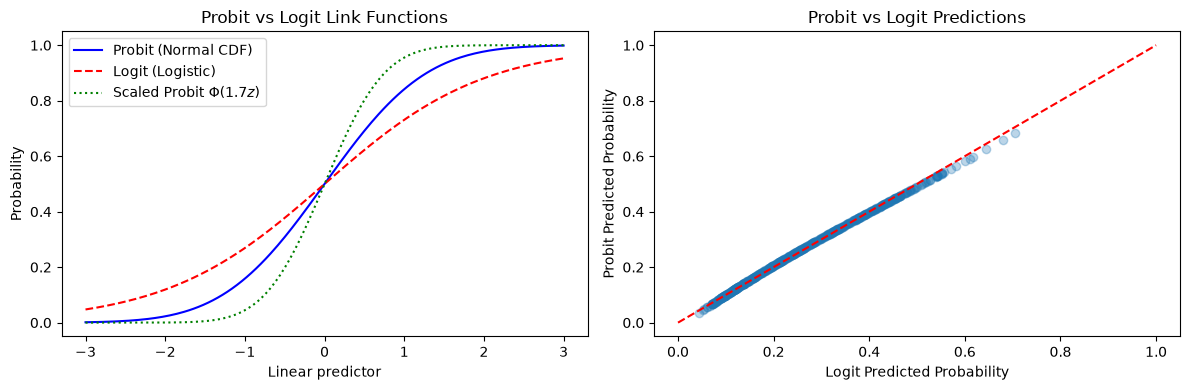

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.special import expit
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ---- Scratch Probit ----
class ProbitModel:
    def __init__(self):
        self.coef_ = None

    def _neg_ll(self, beta, X, y):
        xb = X @ beta
        p = norm.cdf(xb)
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

    def _gradient(self, beta, X, y):
        xb = X @ beta
        p = norm.cdf(xb)
        p = np.clip(p, 1e-10, 1 - 1e-10)
        phi = norm.pdf(xb)
        grad = -np.sum(X * ((y / p - (1-y)/(1-p)) * phi)[:, None], axis=0)
        return grad

    def fit(self, X, y):
        X_b = np.column_stack([np.ones(len(X)), X])
        beta0 = np.zeros(X_b.shape[1])
        res = minimize(self._neg_ll, beta0, args=(X_b, y),
                      jac=self._gradient, method='L-BFGS-B')
        self.coef_ = res.x
        return self

    def predict_proba(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return norm.cdf(X_b @ self.coef_)

    def marginal_effects(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        phi = norm.pdf(X_b @ self.coef_)
        return np.mean(phi) * self.coef_[1:]  # exclude intercept

# Generate binary data: loan default
np.random.seed(42)
n = 500
income = np.random.normal(50, 15, n)
debt_ratio = np.random.uniform(0, 1, n)
y_star = -1 + 0.02*income - 1.5*debt_ratio + np.random.randn(n)
y_probit = (y_star > 0).astype(int)

X_probit = np.column_stack([income, debt_ratio])
X_std = (X_probit - X_probit.mean(0)) / X_probit.std(0)

# Scratch Probit
probit = ProbitModel()
probit.fit(X_std, y_probit)
prob_pred = probit.predict_proba(X_std)
ame = probit.marginal_effects(X_std)
print('Scratch Probit:')
print(f'  Coefficients: {probit.coef_}')
print(f'  Average Marginal Effects: {ame}')
print(f'  AUC: {roc_auc_score(y_probit, prob_pred):.4f}')

# Statsmodels Probit
X_sm = sm.add_constant(X_probit)
probit_sm = sm.Probit(y_probit, X_sm).fit(disp=False)
print('\nStatsmodels Probit:')
print(probit_sm.summary().tables[1])
margeff = probit_sm.get_margeff()
print('\nAverage Marginal Effects:')
print(margeff.summary())

# Compare Probit vs Logit
logit_sm = sm.Logit(y_probit, X_sm).fit(disp=False)
print(f'\nProbit AIC: {probit_sm.aic:.2f}')
print(f'Logit AIC:  {logit_sm.aic:.2f}')

# Visualize decision boundary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
z = np.linspace(-3, 3, 200)
axes[0].plot(z, norm.cdf(z), 'b-', label='Probit (Normal CDF)')
axes[0].plot(z, expit(z), 'r--', label='Logit (Logistic)')
axes[0].plot(z, norm.cdf(1.7*z), 'g:', label='Scaled Probit $\\Phi(1.7z)$')
axes[0].set_xlabel('Linear predictor')
axes[0].set_ylabel('Probability')
axes[0].set_title('Probit vs Logit Link Functions')
axes[0].legend()

pred_probit = probit_sm.predict(X_sm)
pred_logit = logit_sm.predict(X_sm)
axes[1].scatter(pred_logit, pred_probit, alpha=0.3)
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_xlabel('Logit Predicted Probability')
axes[1].set_ylabel('Probit Predicted Probability')
axes[1].set_title('Probit vs Logit Predictions')
plt.tight_layout()
plt.show()


## 9. Gaussian Discriminant Analysis (GDA)

**Gaussian Discriminant Analysis** is a generative classification model that assumes each class follows a multivariate Gaussian distribution.

### Generative Model

$$P(Y = k) = \pi_k \quad (\text{class prior})$$
$$P(\mathbf{X} | Y = k) = \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \quad (\text{class-conditional density})$$

### Bayes' Theorem for Classification

$$P(Y = k | \mathbf{x}) = \frac{P(\mathbf{x} | Y=k) P(Y=k)}{\sum_j P(\mathbf{x} | Y=j) P(Y=j)}$$

### Maximum Likelihood Estimates

$$\hat{\pi}_k = \frac{n_k}{n}, \quad \hat{\boldsymbol{\mu}}_k = \frac{1}{n_k}\sum_{y_i=k} \mathbf{x}_i$$
$$\hat{\boldsymbol{\Sigma}}_k = \frac{1}{n_k}\sum_{y_i=k} (\mathbf{x}_i - \hat{\boldsymbol{\mu}}_k)(\mathbf{x}_i - \hat{\boldsymbol{\mu}}_k)^T$$

### GDA as Special Case

- If $\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}$ (shared covariance) → **LDA** (linear boundary)
- If $\boldsymbol{\Sigma}_k$ differs per class → **QDA** (quadratic boundary)

### Relationship to Logistic Regression

When GDA assumptions hold, the posterior $P(Y=1|\mathbf{x})$ takes the logistic form:
$$P(Y=1|\mathbf{x}) = \sigma(\boldsymbol{\theta}^T \mathbf{x}) \quad \text{when } \boldsymbol{\Sigma}_0 = \boldsymbol{\Sigma}_1$$

**GDA is more efficient** when Gaussian assumption holds; **logistic regression is more robust** when it doesn't.


GDA Results:
  Accuracy: 0.9289
  Class priors: ['0.33', '0.33', '0.33']
  Class means: [array([0.03, 0.04]), array([3.01, 1.95]), array([0.9 , 4.07])]


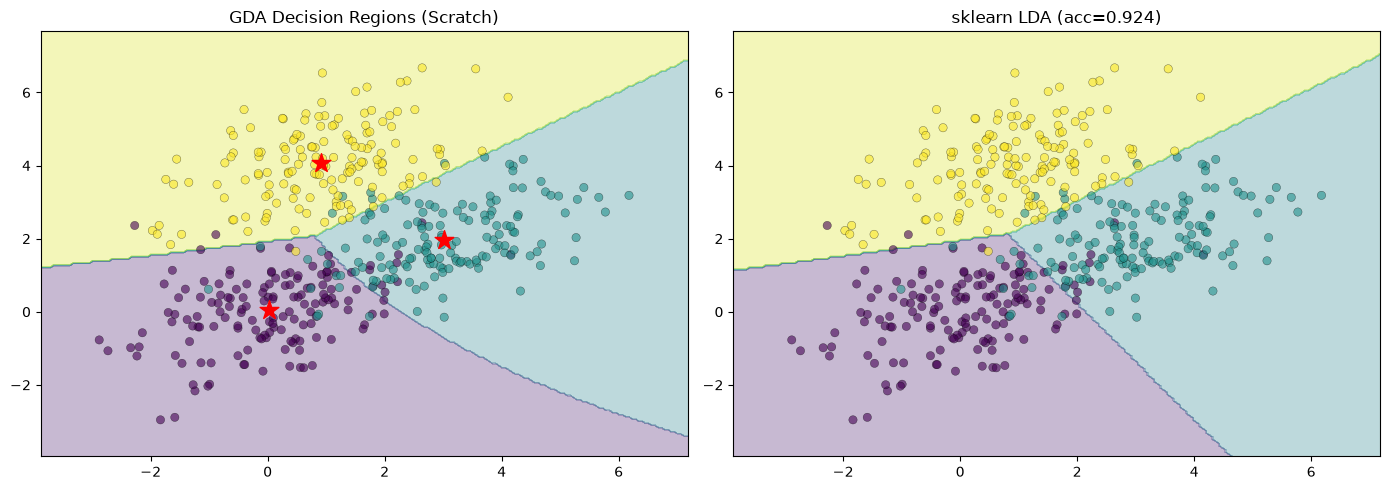

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import make_classification

# ---- Scratch GDA ----
class GDA:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.covs_ = {}
        n = len(y)
        for k in self.classes_:
            X_k = X[y == k]
            self.priors_[k] = len(X_k) / n
            self.means_[k] = X_k.mean(axis=0)
            self.covs_[k] = np.cov(X_k.T)
        return self

    def predict_proba(self, X):
        probs = np.zeros((len(X), len(self.classes_)))
        for i, k in enumerate(self.classes_):
            probs[:, i] = (self.priors_[k] *
                          multivariate_normal.pdf(X, self.means_[k], self.covs_[k]))
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

# Generate 2D Gaussian data
np.random.seed(42)
n_per_class = 150
mu1 = np.array([0, 0])
mu2 = np.array([3, 2])
mu3 = np.array([1, 4])
Sigma = np.array([[1.5, 0.5], [0.5, 1.0]])

X1 = np.random.multivariate_normal(mu1, Sigma, n_per_class)
X2 = np.random.multivariate_normal(mu2, Sigma, n_per_class)
X3 = np.random.multivariate_normal(mu3, Sigma, n_per_class)
X_gda = np.vstack([X1, X2, X3])
y_gda = np.array([0]*n_per_class + [1]*n_per_class + [2]*n_per_class)

gda = GDA()
gda.fit(X_gda, y_gda)
y_pred = gda.predict(X_gda)
print('GDA Results:')
print(f'  Accuracy: {np.mean(y_pred == y_gda):.4f}')
print(f'  Class priors: {[f"{gda.priors_[k]:.2f}" for k in gda.classes_]}')
print(f'  Class means: {[gda.means_[k].round(2) for k in gda.classes_]}')

# Visualize decision regions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_min, x_max = X_gda[:,0].min()-1, X_gda[:,0].max()+1
y_min, y_max = X_gda[:,1].min()-1, X_gda[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_gda = gda.predict(grid).reshape(xx.shape)
axes[0].contourf(xx, yy, Z_gda, alpha=0.3, cmap='viridis')
scatter = axes[0].scatter(X_gda[:,0], X_gda[:,1], c=y_gda, cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.3)
for k in gda.classes_:
    axes[0].scatter(*gda.means_[k], s=200, marker='*', c='red', zorder=10)
axes[0].set_title('GDA Decision Regions (Scratch)')

lda_sk = LinearDiscriminantAnalysis()
lda_sk.fit(X_gda, y_gda)
Z_lda = lda_sk.predict(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_lda, alpha=0.3, cmap='viridis')
axes[1].scatter(X_gda[:,0], X_gda[:,1], c=y_gda, cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.3)
axes[1].set_title(f'sklearn LDA (acc={lda_sk.score(X_gda,y_gda):.3f})')
plt.tight_layout()
plt.show()


## 10. Quadratic Discriminant Analysis (QDA)

**QDA** relaxes the LDA assumption of equal covariance matrices, allowing each class to have its own covariance $\boldsymbol{\Sigma}_k$. This results in **quadratic decision boundaries**.

### Discriminant Function

The log posterior (ignoring constant terms) is:
$$\delta_k(\mathbf{x}) = -\frac{1}{2}\log|\boldsymbol{\Sigma}_k| - \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) + \log \pi_k$$

### Decision Boundary

The boundary between classes $j$ and $k$ is a **quadratic surface**:
$$\delta_j(\mathbf{x}) = \delta_k(\mathbf{x})$$

This expands to:
$$\mathbf{x}^T \mathbf{A} \mathbf{x} + \mathbf{b}^T \mathbf{x} + c = 0$$

where $\mathbf{A} = \frac{1}{2}(\boldsymbol{\Sigma}_k^{-1} - \boldsymbol{\Sigma}_j^{-1})$.

### LDA vs QDA Trade-off

| | LDA | QDA |
|---|---|---|
| Parameters | $O(Kp + p^2)$ | $O(Kp^2)$ |
| Boundary | Linear | Quadratic |
| Assumption | $\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}$ | $\boldsymbol{\Sigma}_k$ free |
| Bias | Higher | Lower |
| Variance | Lower | Higher |

### When QDA Wins

Use QDA when:
- Different classes have clearly different scatter/shape
- Enough data to reliably estimate separate covariance matrices
- The equal-covariance assumption of LDA is clearly violated


QDA Scratch Accuracy: 0.9867
LDA sklearn Accuracy: 0.9867
QDA sklearn Accuracy: 0.9867


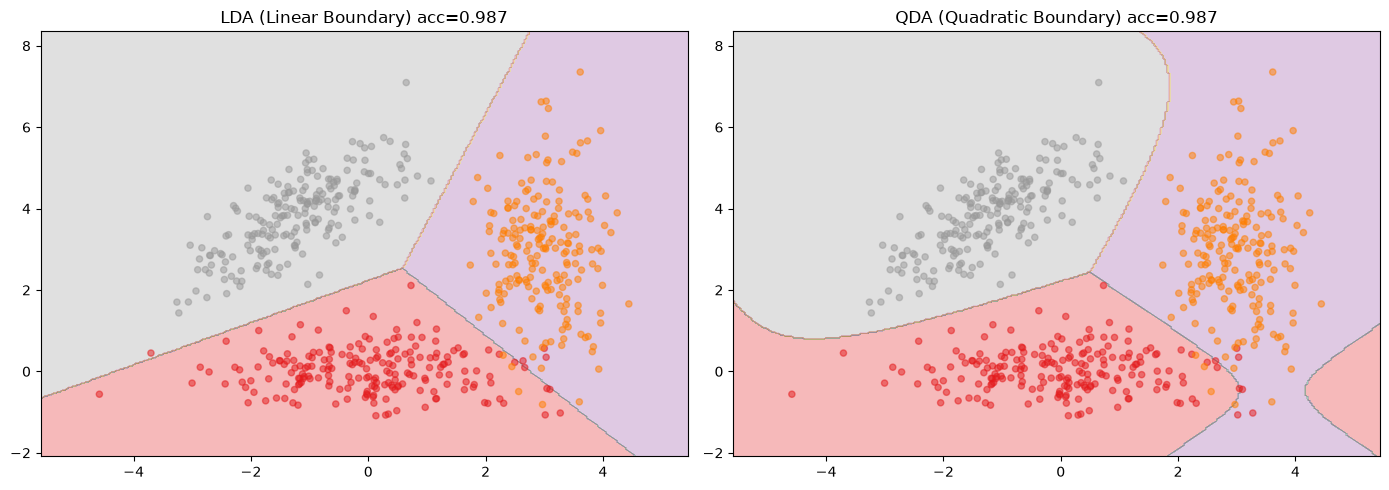

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---- Scratch QDA ----
class QDA:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.covs_ = {}
        n = len(y)
        for k in self.classes_:
            X_k = X[y == k]
            self.priors_[k] = len(X_k) / n
            self.means_[k] = X_k.mean(0)
            self.covs_[k] = np.cov(X_k.T) + 1e-6 * np.eye(X.shape[1])
        return self

    def discriminant(self, X, k):
        mu = self.means_[k]
        Sigma = self.covs_[k]
        sign, logdet = np.linalg.slogdet(Sigma)
        diff = X - mu
        Sigma_inv = np.linalg.inv(Sigma)
        quad = -0.5 * np.sum(diff @ Sigma_inv * diff, axis=1)
        return quad - 0.5 * logdet + np.log(self.priors_[k])

    def predict(self, X):
        scores = np.column_stack([self.discriminant(X, k) for k in self.classes_])
        return self.classes_[np.argmax(scores, axis=1)]

# Generate data with different covariance structures
np.random.seed(42)
n = 200
X_c0 = np.random.multivariate_normal([0, 0], [[2, 0], [0, 0.3]], n)
X_c1 = np.random.multivariate_normal([3, 3], [[0.3, 0], [0, 2]], n)
X_c2 = np.random.multivariate_normal([-1, 4], [[1, 0.8], [0.8, 1]], n)
X_qda = np.vstack([X_c0, X_c1, X_c2])
y_qda = np.array([0]*n + [1]*n + [2]*n)

qda_scratch = QDA()
qda_scratch.fit(X_qda, y_qda)
acc_scratch = np.mean(qda_scratch.predict(X_qda) == y_qda)

lda_sk = LinearDiscriminantAnalysis()
qda_sk = QuadraticDiscriminantAnalysis()
lda_sk.fit(X_qda, y_qda)
qda_sk.fit(X_qda, y_qda)

print(f'QDA Scratch Accuracy: {acc_scratch:.4f}')
print(f'LDA sklearn Accuracy: {lda_sk.score(X_qda, y_qda):.4f}')
print(f'QDA sklearn Accuracy: {qda_sk.score(X_qda, y_qda):.4f}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_min, x_max = X_qda[:,0].min()-1, X_qda[:,0].max()+1
y_min, y_max = X_qda[:,1].min()-1, X_qda[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lda = lda_sk.predict(grid).reshape(xx.shape)
Z_qda = qda_sk.predict(grid).reshape(xx.shape)

axes[0].contourf(xx, yy, Z_lda, alpha=0.3, cmap='Set1')
axes[0].scatter(X_qda[:,0], X_qda[:,1], c=y_qda, cmap='Set1', alpha=0.5, s=20)
axes[0].set_title(f'LDA (Linear Boundary) acc={lda_sk.score(X_qda,y_qda):.3f}')

axes[1].contourf(xx, yy, Z_qda, alpha=0.3, cmap='Set1')
axes[1].scatter(X_qda[:,0], X_qda[:,1], c=y_qda, cmap='Set1', alpha=0.5, s=20)
axes[1].set_title(f'QDA (Quadratic Boundary) acc={qda_sk.score(X_qda,y_qda):.3f}')
plt.tight_layout()
plt.show()


## 11. Linear Discriminant Analysis (LDA)

**LDA** finds a projection that maximizes **class separation** while minimizing **within-class variance** the Fisher criterion.

### Fisher's Criterion

Find projection vector $\mathbf{w}$ that maximizes the **Fisher ratio**:
$$J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$$

where:
- $\mathbf{S}_B = \sum_k n_k (\boldsymbol{\mu}_k - \boldsymbol{\mu})(\boldsymbol{\mu}_k - \boldsymbol{\mu})^T$ is the **between-class scatter** matrix
- $\mathbf{S}_W = \sum_k \sum_{y_i=k} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^T$ is the **within-class scatter** matrix

### Solution

The optimal $\mathbf{w}$ is the leading eigenvector(s) of $\mathbf{S}_W^{-1} \mathbf{S}_B$:
$$\mathbf{S}_W^{-1} \mathbf{S}_B \mathbf{w} = \lambda \mathbf{w}$$

For $K$ classes, there are at most $K-1$ non-zero eigenvalues, giving $K-1$ discriminant directions.

### Decision Rule

Project $\mathbf{x}$ onto $\mathbf{w}$ and assign to the nearest class centroid in the projected space:
$$\hat{y} = \arg\min_k \|\mathbf{w}^T \mathbf{x} - \mathbf{w}^T \boldsymbol{\mu}_k\|^2 - 2\log \pi_k$$

### LDA for Dimensionality Reduction

LDA also serves as a supervised dimensionality reduction technique: project data onto the top $K-1$ discriminant vectors before classification.

### Assumptions

1. Features are multivariate Gaussian within each class
2. Equal covariance matrices across classes
3. Classes are linearly separable (in transformed space)


Scratch LDA:
  Accuracy: 0.9667
  Explained variance ratio: [0.9912126 0.0087874]

sklearn LDA:
  Accuracy: 0.9800
  Explained variance ratio: [0.9912126 0.0087874]


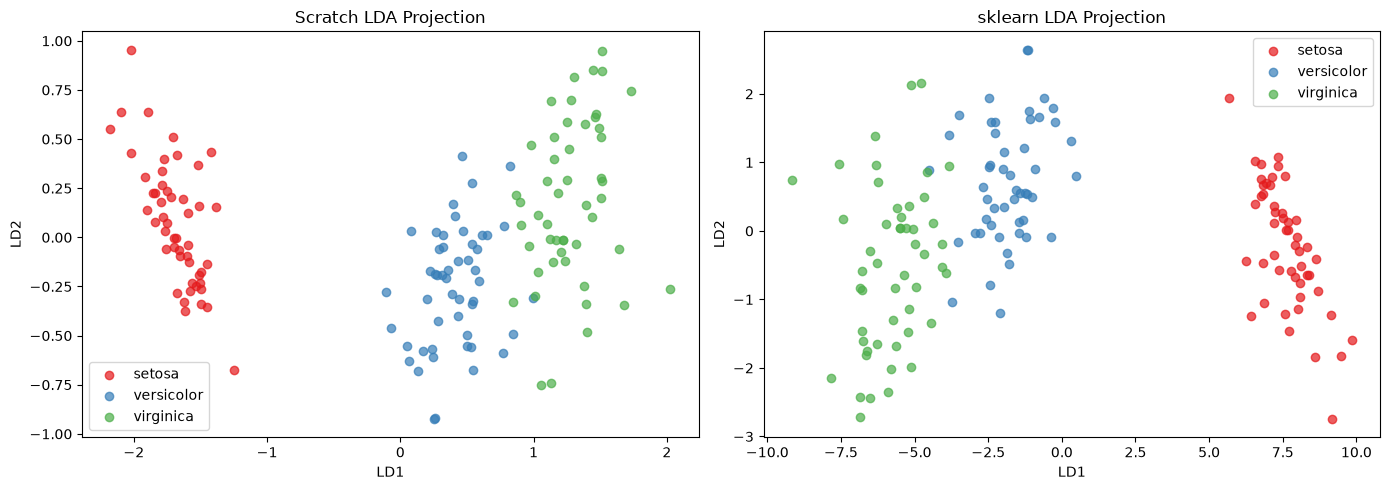


Fisher Ratio per Feature (between/within variance):
  sepal length (cm): F = 1.6226
  sepal width (cm): F = 0.6688
  petal length (cm): F = 16.0566
  petal width (cm): F = 13.0613


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# ---- Scratch LDA ----
class LDA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        n, p = X.shape
        self.overall_mean_ = X.mean(0)
        self.class_means_ = np.array([X[y==k].mean(0) for k in self.classes_])
        self.priors_ = np.array([np.mean(y==k) for k in self.classes_])

        # Between-class scatter
        S_B = np.zeros((p, p))
        for i, k in enumerate(self.classes_):
            n_k = np.sum(y == k)
            diff = (self.class_means_[i] - self.overall_mean_).reshape(-1, 1)
            S_B += n_k * diff @ diff.T

        # Within-class scatter
        S_W = np.zeros((p, p))
        for i, k in enumerate(self.classes_):
            X_k = X[y == k]
            diff = X_k - self.class_means_[i]
            S_W += diff.T @ diff

        # Solve generalized eigenvalue problem
        eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W) @ S_B)
        eigvals = eigvals.real
        eigvecs = eigvecs.real
        order = np.argsort(eigvals)[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]

        n_comp = self.n_components or min(K-1, p)
        self.components_ = eigvecs[:, :n_comp].T
        self.explained_variance_ratio_ = eigvals[:n_comp] / eigvals.sum()
        return self

    def transform(self, X):
        return (X - self.overall_mean_) @ self.components_.T

    def predict(self, X):
        X_proj = self.transform(X)
        means_proj = (self.class_means_ - self.overall_mean_) @ self.components_.T
        scores = np.array([
            np.sum((X_proj - mu)**2, axis=1) - 2*np.log(p)
            for mu, p in zip(means_proj, self.priors_)
        ]).T
        return self.classes_[np.argmin(scores, axis=1)]

# Iris dataset demo
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Scratch LDA
lda_scratch = LDA(n_components=2)
lda_scratch.fit(X_scaled, y_iris)
X_lda = lda_scratch.transform(X_scaled)
acc_scratch = np.mean(lda_scratch.predict(X_scaled) == y_iris)

print('Scratch LDA:')
print(f'  Accuracy: {acc_scratch:.4f}')
print(f'  Explained variance ratio: {lda_scratch.explained_variance_ratio_}')

# sklearn LDA
lda_sk = LinearDiscriminantAnalysis(n_components=2)
lda_sk.fit(X_scaled, y_iris)
X_lda_sk = lda_sk.transform(X_scaled)
print(f'\nsklearn LDA:')
print(f'  Accuracy: {lda_sk.score(X_scaled, y_iris):.4f}')
print(f'  Explained variance ratio: {lda_sk.explained_variance_ratio_}')

# Visualize LDA projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for i, (name, color) in enumerate(zip(iris.target_names, colors)):
    axes[0].scatter(X_lda[y_iris==i, 0], X_lda[y_iris==i, 1],
                   label=name, color=color, alpha=0.7)
axes[0].set_xlabel('LD1')
axes[0].set_ylabel('LD2')
axes[0].set_title('Scratch LDA Projection')
axes[0].legend()

for i, (name, color) in enumerate(zip(iris.target_names, colors)):
    axes[1].scatter(X_lda_sk[y_iris==i, 0], X_lda_sk[y_iris==i, 1],
                   label=name, color=color, alpha=0.7)
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].set_title('sklearn LDA Projection')
axes[1].legend()
plt.tight_layout()
plt.show()

# Fisher ratio for each feature
print('\nFisher Ratio per Feature (between/within variance):')
for i, fname in enumerate(feature_names):
    overall_mean = X_iris[:, i].mean()
    sb = sum(np.sum(y_iris==k) * (X_iris[y_iris==k, i].mean() - overall_mean)**2
             for k in np.unique(y_iris))
    sw = sum(np.sum((X_iris[y_iris==k, i] - X_iris[y_iris==k, i].mean())**2)
             for k in np.unique(y_iris))
    print(f'  {fname}: F = {sb/sw:.4f}')


## 12. Multi-class Confusion Matrix

A **confusion matrix** summarizes classification performance across multiple classes at a glance.

### How to Read a Multi-class Confusion Matrix

- **Each row** represents the **true class** (actual label)
- **Each column** represents the **predicted class** (model output)
- The **diagonal** entries are **correct predictions**, the count where true class equals predicted class
- **Off-diagonal** entries are misclassifications: entry $(i, j)$ with $i \neq j$ means the model predicted class $j$ when the true class was $i$

For example, a value of 5 at row 'setosa', column 'versicolor' would mean 5 setosa samples were incorrectly predicted as versicolor.

### Interpreting Class-level Performance

- **Row sums** give the total number of samples in each true class
- **Column sums** give the total number of predictions for each class
- High off-diagonal values in a row indicate that class is being confused with other classes (low recall)
- High off-diagonal values in a column indicate a class is being over-predicted (low precision)

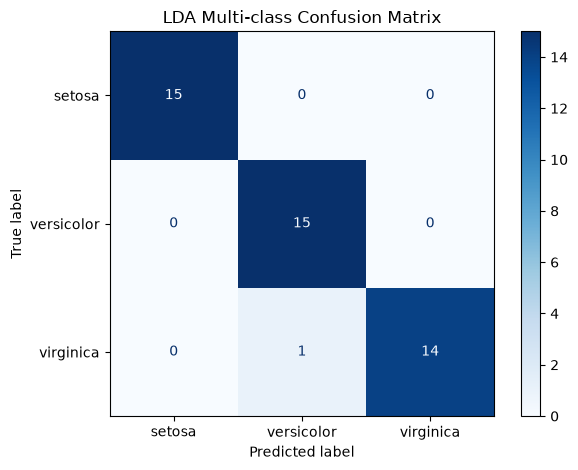

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_iris, y_iris = load_iris(return_X_y=True)
X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, stratify=y_iris, random_state=42
)

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr_iris, y_tr_iris)
y_pred_iris = lda.predict(X_te_iris)

cm = confusion_matrix(y_te_iris, y_pred_iris)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=load_iris().target_names)
disp.plot(cmap='Blues')
plt.title('LDA Multi-class Confusion Matrix')
plt.tight_layout()
plt.show()

## 13. Model Persistence with joblib

**joblib** is the preferred tool for serializing (saving and loading) scikit-learn and statsmodels objects in Python. It is preferred over the standard `pickle` module for models that contain **large numpy arrays**, such as fitted GLM coefficient arrays, weight matrices, or cached design matrices, because joblib uses memory-mapped files and efficient compression, making it significantly faster and more memory-efficient for numerical data.

### When to Use joblib vs pickle

| Scenario | Recommendation |
|---|---|
| Model with large numpy arrays (sklearn, statsmodels) | `joblib.dump` / `joblib.load` |
| Small pure-Python objects | `pickle` is fine |
| Cross-language portability | Neither; use ONNX or PMML |
| Long-term storage | Add version checks; models may not reload after library upgrades |

### Workflow

1. Fit the model
2. Save with `joblib.dump(model, path)`
3. Load anywhere with `joblib.load(path)`
4. Predictions from the loaded model are identical to the original

In [14]:
import joblib
import os

output_path = '/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/03_Machine_Learning/01_supervised/best_glm_model.pkl'
joblib.dump(gamma_result, output_path)
print(f'Model saved to: {output_path}')

loaded = joblib.load(output_path)
print('Model loaded successfully')
print('Predictions match:', np.allclose(gamma_result.predict(X_gamma_sm), loaded.predict(X_gamma_sm)))

os.remove(output_path)
print('Temp file cleaned up')

Model saved to: /home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/03_Machine_Learning/01_supervised/best_glm_model.pkl
Model loaded successfully
Predictions match: True
Temp file cleaned up


## Additional Learning Resources

### Foundational Papers

1. **Nelder & Wedderburn (1972)** "Generalized Linear Models" *Journal of the Royal Statistical Society*  
   The original GLM paper introducing the unified framework.

2. **McCullagh & Nelder (1989)** *Generalized Linear Models* (2nd ed.) Chapman & Hall  
   The definitive textbook reference.

3. **Fisher (1936)** "The Use of Multiple Measurements in Taxonomic Problems" *Annals of Eugenics*  
   The original LDA paper: https://doi.org/10.1111/j.1469-1809.1936.tb02137.x

4. **Lambert (1992)** "Zero-Inflated Poisson Regression, with an Application to Defects in Manufacturing" *Technometrics*  
   Introduced ZIP regression.

5. **Tobin (1958)** "Estimation of Relationships for Limited Dependent Variables" *Econometrica*  
   Original Tobit model paper.

### Books

6. **Agresti (2015)** *Foundations of Linear and Generalized Linear Models* Wiley  
   Excellent modern treatment covering ordinal models, GLMs, and extensions.

7. **Hastie, Tibshirani & Friedman (2009)** *The Elements of Statistical Learning* (free PDF)  
   https://hastie.su.domains/ElemStatLearn/ Chapters 4 (LDA/QDA) and 7 (model selection)

8. **Cameron & Trivedi (2013)** *Regression Analysis of Count Data* (2nd ed.) Cambridge  
   Comprehensive treatment of Poisson, NB, ZIP, ZINB.

### Online Courses & Tutorials

9. **statsmodels Documentation** https://www.statsmodels.org/stable/glm.html  
   GLM in Python with examples for all families.

10. **scikit-learn User Guide: LDA/QDA** https://scikit-learn.org/stable/modules/lda_qda.html  
    Implementation details and examples.

11. **Andrew Ng's CS229 Lecture Notes** https://cs229.stanford.edu/notes2022fall/main_notes.pdf  
    Chapter on Generative Learning Algorithms covers GDA, LDA.

12. **Penn State STAT 504** https://online.stat.psu.edu/stat504/  
    Free online course covering GLMs, Poisson, and ordinal models.

### Key Python Libraries

```python
import statsmodels.api as sm                          # GLM, Poisson, NB, Probit, Tobit
from statsmodels.discrete.count_model import (        # ZIP, ZINB
    ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP)
from statsmodels.miscmodels.ordinal_model import (     # Ordinal regression
    OrderedModel)
from sklearn.discriminant_analysis import (            # LDA, QDA
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)
```

### Practical Guidance: Model Selection Flowchart

```
Outcome type?
├── Continuous
│   ├── Uncensored → Linear Regression / Gaussian GLM
│   └── Censored at threshold → Tobit Model
├── Binary → Logistic / Probit Regression
├── Ordinal categories → Ordinal (Proportional Odds) Regression
└── Count data
    ├── Check: Var/Mean ≈ 1? → Poisson
    ├── Check: Var/Mean >> 1 (overdispersed)? → Negative Binomial
    ├── Check: Excess zeros? → ZIP (if equidispersed) or ZINB (if overdispersed)
    └── Compare AIC across models
```
